Classification to identify language of given sentences
GOAL = categorize into different languages

In [50]:
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2026-04-21 22:05:23.935500


In [51]:
# !pip install tensorflow-macos tensorflow-metal

In [52]:
# data handling
import pandas as pd
import numpy as np

# model building
import tensorflow as tf
from keras import preprocessing, models, layers, initializers, Input, optimizers
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, RNN, LSTMCell, Dropout
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import RMSprop

# model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# model evaluation and interpretation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [53]:
print(tf.__version__)

2.19.0


In [54]:
# are we using a gpu
print(tf.config.list_physical_devices('GPU'))

[]


EXPLORATORY DATA ANALYSIS

In [55]:
df_1 = pd.read_csv("sentences.eng.200k.txt", sep="\t") # for tab-delimited
df_2 = pd.read_csv("sentences.top10langs.dev.tsv", sep="\t")
df_3 = pd.read_csv("sentences.top10langs.train.tsv", sep="\t")

In [56]:
print(f"Dataframe 1:" ,{df_1.shape})
print(f"Dataframe 2:" ,{df_2.shape})
print(f"Dataframe 3:" ,{df_3.shape})

Dataframe 1: {(199999, 1)}
Dataframe 2: {(9999, 2)}
Dataframe 3: {(99862, 2)}


In [57]:
# check missing values
df_1.isnull().sum()

,0
Let's try something.,0


In [58]:
df_1.isna().sum()

,0
Let's try something.,0


In [59]:
df_2.isnull().sum()

,0
por,0
"De entre os designers, ele escolheu um jovem ilustrador e deu-lhe a tarefa.",0


In [60]:
df_3.isnull().sum()

,0
spa,0
"Te di mi corazón para que lo ames, ¡no para usarlo!",0


In [61]:
df_1.head()

,Let's try something.
0,I have to go to sleep.
1,Today is June 18th and it is Muiriel's birthday!
2,Muiriel is 20 now.
3,"The password is ""Muiriel""."
4,I will be back soon.


In [62]:
df_2.head()

,por,"De entre os designers, ele escolheu um jovem ilustrador e deu-lhe a tarefa."
0,por,"Na semana que vem, tudo será diferente."
1,por,Tu deverias realmente beber menos café.
2,por,Isto é um lenço.
3,por,Os campistas prudentes tinham suficientemente ...
4,por,Ele ganhou a aposta.


In [63]:
df_3.head()

,spa,"Te di mi corazón para que lo ames, ¡no para usarlo!"
0,spa,Contamos con tu ayuda.
1,spa,Tú eres superficial y materialista.
2,spa,Los límites son para los demás.
3,spa,Todos ellos esperaron ansiosamente las vacacio...
4,spa,Repentinamente notó que le faltaba su billetera.


For easier data pre-processing, concatenate all three dataframes into one

In [64]:
# df_1 seems to have the first sentence as a header.
# Let's see the actual column names to use the right one for .unique()
print("Columns in df_1:", df_1.columns.tolist())

# To get unique sentences in df_1 (which is just one column of text):
# Replace 'Let\'s try something.' with whatever the print statement above shows if different
unique_sentences = df_1.iloc[:, 0].unique()
print(f"Number of unique sentences in df_1: {len(unique_sentences)}")

Columns in df_1: ["Let's try something."]
Number of unique sentences in df_1: 199998


In [65]:
# Reload df_1 correctly without a header and label it as English
df_1 = pd.read_csv('sentences.eng.200k.txt', sep='\t', names=['text'])
df_1.insert(0, 'lang', 'eng') # 0 is the position for the first column
df_1.rename(columns={df_1.columns[1]:'sentence'}, inplace=True)

# Rename columns for df_2 and df_3 to match
# They currently have the first row as header too, let's reload them properly
df_2 = pd.read_csv('sentences.top10langs.dev.tsv', sep='\t', names=['lang', 'sentence'])
df_3 = pd.read_csv('sentences.top10langs.train.tsv', sep='\t', names=['lang', 'sentence'])

print("Dataframes reloaded and normalized.")
print(f"df_1 columns: {df_1.columns.tolist()}")
print(df_2.head(5))

Dataframes reloaded and normalized.
df_1 columns: ['lang', 'sentence']
  lang                                           sentence
0  por  De entre os designers, ele escolheu um jovem i...
1  por            Na semana que vem, tudo será diferente.
2  por            Tu deverias realmente beber menos café.
3  por                                   Isto é um lenço.
4  por  Os campistas prudentes tinham suficientemente ...


Note: `df_2` and `df_3` have a language label column (like 'por' or 'spa'), but `df_1` appears to be a list of English sentences only. If you want to reload `df_1` correctly so the first line isn't a header, you can use `df_1 = pd.read_csv('sentences.eng.200k.txt', sep='\t', names=['sentence'])`.

In [66]:
df_1

,lang,sentence
0,eng,Let's try something.
1,eng,I have to go to sleep.
2,eng,Today is June 18th and it is Muiriel's birthday!
3,eng,Muiriel is 20 now.
4,eng,"The password is ""Muiriel""."
...,...,...
199995,eng,The brother wrote a letter to the sister.
199996,eng,Wine is the milk of old men.
199997,eng,The sheep in the field are eating grass.
199998,eng,He's a teetotaller.


In [67]:
df_1["lang"].unique()

array(['eng'], dtype=object)

In [68]:
df_2

,lang,sentence
0,por,"De entre os designers, ele escolheu um jovem i..."
1,por,"Na semana que vem, tudo será diferente."
2,por,Tu deverias realmente beber menos café.
3,por,Isto é um lenço.
4,por,Os campistas prudentes tinham suficientemente ...
...,...,...
9995,spa,¿Debo empezar en seguida?
9996,spa,¡Qué galletita crocante!
9997,spa,Esta casa es demasiado chica para vivir.
9998,spa,Los pájaros cantan en los árboles.


In [69]:
df_2["lang"].unique()

array(['por', 'tur', 'ber', 'eng', 'hun', 'epo', 'fra', 'deu', 'ita',
       'spa'], dtype=object)

In [70]:
df_3

,lang,sentence
0,spa,"Te di mi corazón para que lo ames, ¡no para us..."
1,spa,Contamos con tu ayuda.
2,spa,Tú eres superficial y materialista.
3,spa,Los límites son para los demás.
4,spa,Todos ellos esperaron ansiosamente las vacacio...
...,...,...
99858,eng,It sure sounds interesting.
99859,eng,That's what friends are for.
99860,eng,She had a puzzled look on her face.
99861,eng,What did Tom wear?


In [71]:
df_3["lang"].unique()

array(['spa', 'deu', 'tur', 'fra', 'por', 'epo', 'ita', 'hun', 'ber',
       'eng'], dtype=object)

In [72]:
# concatenation - 3 datasets to 1 dataframe
df_concat = pd.concat([df_1, df_2, df_3], axis=0) # concatenate in row way, axis=0
print('concatenated rows')

concatenated rows


In [73]:
df_concat.shape

(309863, 2)

In [74]:
df_concat.head()

,lang,sentence
0,eng,Let's try something.
1,eng,I have to go to sleep.
2,eng,Today is June 18th and it is Muiriel's birthday!
3,eng,Muiriel is 20 now.
4,eng,"The password is ""Muiriel""."


In [75]:
df_concat.tail()

,lang,sentence
99858,eng,It sure sounds interesting.
99859,eng,That's what friends are for.
99860,eng,She had a puzzled look on her face.
99861,eng,What did Tom wear?
99862,eng,Hanako has forgotten her umbrella again.


In [76]:
df_concat['lang'].unique()

array(['eng', 'por', 'tur', 'ber', 'hun', 'epo', 'fra', 'deu', 'ita',
       'spa'], dtype=object)

In [77]:
num_classes = df_concat['lang'].nunique()
num_classes

10

<Axes: xlabel='lang'>

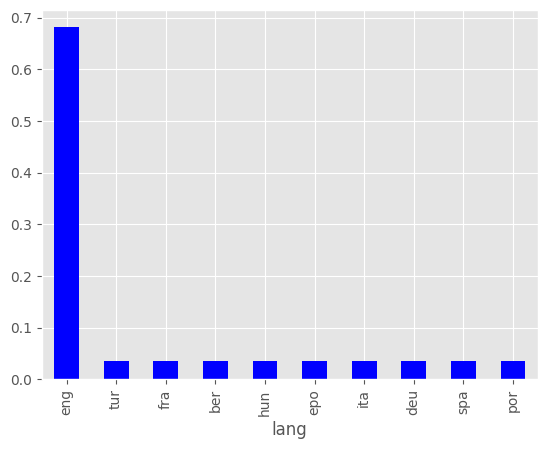

In [78]:
# check target balance
df_concat['lang'].value_counts(normalize=True).plot.bar(color='blue')

EXTRACT FEATURES AND LABELS FROM NUMPY DATAFRAME

In [79]:
# features and labels
X = df_concat['sentence'].values # features(text)-.values converts the features to np array
y = df_concat['lang'].values # labels-.values converts labels into np array

# encode the labels in numerical format
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)

# split into training and testing sets
X_train, X_test, y_train, y_test, = train_test_split(X, integer_encoded,
                                                     test_size=0.2,
                                                     random_state=33)

# create an instance of text vectorization layer
max_vocab_length = 20000 # maximum number of words in the vocabulary
avg_sequence_length = round(sum([len(i.split()) for i in X_train])/len(X_train))
#average length of sentences to set consistent avg length

# features and variables made numerical to be suitable for the model
text_vectorizer = TextVectorization(max_tokens=max_vocab_length,
                                    output_mode='int',
                                    output_sequence_length=avg_sequence_length)

# adapt the vectorizer to the training data
text_vectorizer.adapt(X_train)

# get the num of unique tokens (vocab size) dataset
max_features = len(text_vectorizer.get_vocabulary()) # vocab size

# convert text data to sequence of integers using the vectorizer
X_train_vectorized = text_vectorizer(X_train)
X_test_vectorized = text_vectorizer(X_test)
# sequence of integers above

# pad the sequences (though TextVectorization already inputs padded sequences if `output_sequence_length` is set)
# ensure all sequences of the same length
# necessary for batch processing in NN
X_train_padded = pad_sequences(X_train_vectorized.numpy(), maxlen=avg_sequence_length,
                               padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_vectorized.numpy(), maxlen=avg_sequence_length,
                              padding='post', truncating='post')

# after padding or truncating, check dimensionality
X_train_padded.shape, X_test_padded.shape


((247890, 8), (61973, 8))

MODEL BUILDING

In [80]:
def model_fit(model, X_train, y_train, X_test, y_test):
  import time
  start = time.time()
  from tensorflow.keras import optimizers
  opt = optimizers.RMSprop(learning_rate=0.0001)

  model.compile(optimizer=opt,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  history = model.fit(X_train_padded, y_train,
                      validation_data = (X_test_padded, y_test),
                      epochs=5)

  end = time.time()
  elapsed_time = end - start
  return elapsed_time, history


In [81]:
def plot_accuracy(history, elapsed_time=None):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(len(acc))

  plt.plot(epochs, acc, 'b',
           label='Training Accuracy')
  plt.plot(epochs, val_acc, 'r--o',
           label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()


  acc = acc[-1] #np.mean(history['accuracy'])
  acc_percentage = str("{:.3f}".format(acc))

  val_acc = val_acc[-1] #np.mean(history['val_acc'])
  val_acc_percentage = str("{:.3f}".format(val_acc))

  plt.legend(['Training Accuracy: '+acc_percentage,
              'Validation Accuracy: '+val_acc_percentage],
             loc='upper left')
  plt.figure()

  plt.plot(epochs, loss, 'b',
           label='Training Loss')
  plt.plot(epochs, val_loss, 'r--o',
           label='Validation Loss')
  plt.title('Training and Validation Loss')


  loss = loss[-1] #np.mean(history['loss'])
  loss_percentage = str("{:.3f}".format(loss))

  val_loss = val_loss[-1] #np.mean(history['loss'])
  val_loss_percentage = str("{:.3f}".format(val_loss))

  plt.legend(['Training Loss: '+loss_percentage,
              'Validation Loss: '+val_loss_percentage],
             loc='upper left')

  plt.show()

  if elapsed_time:
    print("Running time: {} seconds".format(elapsed_time))

In [82]:
def calculate_results(model):
  BATCH_SIZE=32
  score,acc=model.evaluate(X_test_padded, y_test,
                           batch_size=BATCH_SIZE)
  print('test score: ', score)
  print('test accuracy: ', acc)

  # predict the class probabilities
  y_pred_probs = model.predict(X_test_padded)
  y_pred = np.argmax(y_pred_probs, axis=1)

  # y-test already in integer format
  y_true = y_test # true class labels

  # calculate accuracy
  accuracy = accuracy_score(y_true, y_pred)
  print('Accuracy:', accuracy)

  # precision, recall, F1
  precision = precision_score(y_true, y_pred, average='weighted') # macro and micro as needed
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  print('Precision:', precision)
  print('Recall:', recall)
  print('F1 Score:', f1)

  # print detailed classification report
  report = classification_report(y_true, y_pred)
  print('Classification report: \n', report)

  # confusion matrix
  conf_matrix = confusion_matrix(y_true, y_pred)
  print('Confusion matrix: \n', conf_matrix)


SIMPLE RNN

In [83]:
def simple_rnn(max_features, units, maxlen):
  rnn_hidden_dim = units
  word_embedding_dim = 50
  maxlen = X_train_padded.shape[1:]

  model = Sequential()
  model.add(layers.Input(shape=(avg_sequence_length,)))
  # this layer takes each integer in the sequence and embeds it into a 50-d vector
  model.add(Embedding(input_dim=max_features,
            output_dim=word_embedding_dim))

  # identity matrix help stabilize training
  # ReLU introduces non-linearity
  # softmax for multi-class classification
  model.add(SimpleRNN(rnn_hidden_dim,
                      kernel_initializer=initializers.RandomNormal(mean=0.,
                                                                   stddev=0.001),
                      recurrent_initializer=initializers.Identity(gain=1.0),
                      activation='relu'
                      # input_shape=X_train.shape[1:]
                      ))

  model.add(Dense(10, activation='softmax'))
  print(model.summary())

  return model


LSTM

In [84]:
def lstm_model(max_features, units, maxlen):
  embedding_size=50

  model=Sequential()
  model.add(layers.Input(shape=(avg_sequence_length,)))
  model.add(Embedding(input_dim=max_features,
                      output_dim=embedding_size))

  model.add(LSTM(units=units))
  model.add(Dense(10, activation='softmax'))
  print(model.summary())

  return model

GRU

In [85]:
def gru_model(max_features, units, maxlen):
  embedding_size=50

  model=Sequential()
  model.add(layers.Input(shape=(avg_sequence_length,)))
  model.add(Embedding(input_dim=max_features,
                      output_dim=embedding_size))

  model.add(GRU(units=units))
  model.add(Dense(10, activation='softmax'))
  print(model.summary())

  return model

We'll build the following models:

*   Simple RNN
*   LSTM
*   GRU

- construct model
- train model
- make predictions with the model
- track predictions with evaluation metrics

SIMPLE RNN

In [86]:
model_rnn = simple_rnn(max_features, units=10, maxlen=avg_sequence_length)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 8, 50)          │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           610 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,720 (3.82 MB)

 Trainable params: 1,000,720 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

None


In [87]:
elapsed_time, history=model_fit(model_rnn,
                               X_train_padded, y_train,
                               X_test_padded, y_test)

Epoch 1/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 121s 15ms/step - accuracy: 0.7508 - loss: 0.7487 - val_accuracy: 0.8376 - val_loss: 0.4776
Epoch 2/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 132s 14ms/step - accuracy: 0.9112 - loss: 0.3108 - val_accuracy: 0.9439 - val_loss: 0.2076
Epoch 3/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 105s 14ms/step - accuracy: 0.9551 - loss: 0.1628 - val_accuracy: 0.9608 - val_loss: 0.1440
Epoch 4/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 101s 13ms/step - accuracy: 0.9667 - loss: 0.1203 - val_accuracy: 0.9689 - val_loss: 0.1168
Epoch 5/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 86s 11ms/step - accuracy: 0.9726 - loss: 0.0995 - val_accuracy: 0.9711 - val_loss: 0.1032


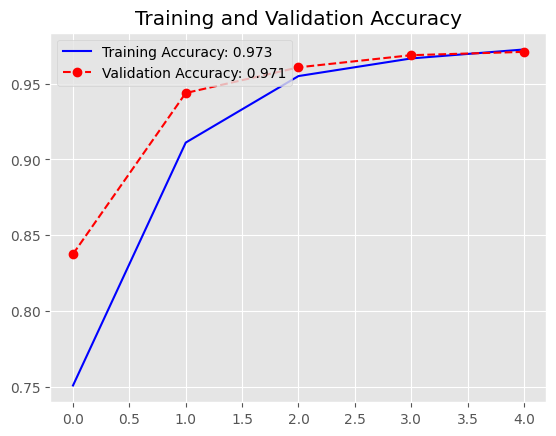

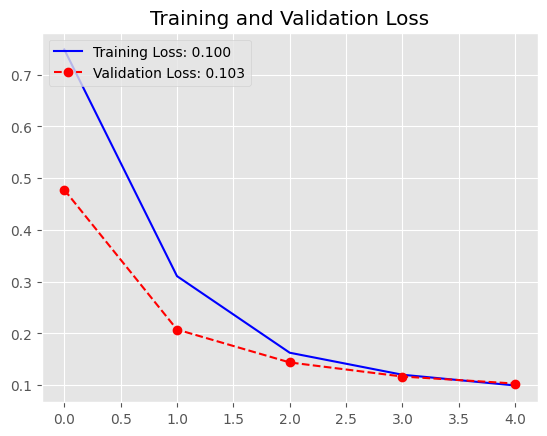

In [88]:
plot_accuracy(history, elapsed_time=None)

In [89]:
calculate_results(model_rnn)

1937/1937 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9711 - loss: 0.1032
test score:  0.10319129377603531
test accuracy:  0.9710519313812256
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Accuracy: 0.9710519097026125
Precision: 0.9722254484499486
Recall: 0.9710519097026125
F1 Score: 0.9712181152932644
Classification report: 
               precision    recall  f1-score   support

           0       0.95      0.85      0.90      2250
           1       0.99      0.95      0.97      2222
           2       1.00      1.00      1.00     42211
           3       0.94      0.96      0.95      2217
           4       0.94      0.91      0.92      2100
           5       0.84      0.89      0.86      2248
           6       0.96      0.90      0.93      2215
           7       0.96      0.89      0.92      2079
           8       0.88      0.93      0.90      2234
           9       0.83      0.96      0.89      2197

    accuracy                           0.97     61973
   macro avg       0.9

LSTM


In [90]:
model_lstm = lstm_model(max_features, units=10, maxlen=avg_sequence_length)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 8, 50)          │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,002,550 (3.82 MB)

 Trainable params: 1,002,550 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

None


In [91]:
elapsed_time, history=model_fit(model_lstm,
                                X_train_padded, y_train,
                                X_test_padded, y_test)

Epoch 1/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 85s 11ms/step - accuracy: 0.7553 - loss: 0.8213 - val_accuracy: 0.8647 - val_loss: 0.4706
Epoch 2/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 104s 13ms/step - accuracy: 0.9317 - loss: 0.3016 - val_accuracy: 0.9572 - val_loss: 0.1993
Epoch 3/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 116s 15ms/step - accuracy: 0.9640 - loss: 0.1563 - val_accuracy: 0.9678 - val_loss: 0.1351
Epoch 4/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 113s 15ms/step - accuracy: 0.9720 - loss: 0.1128 - val_accuracy: 0.9734 - val_loss: 0.1069
Epoch 5/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 111s 14ms/step - accuracy: 0.9764 - loss: 0.0919 - val_accuracy: 0.9758 - val_loss: 0.0914


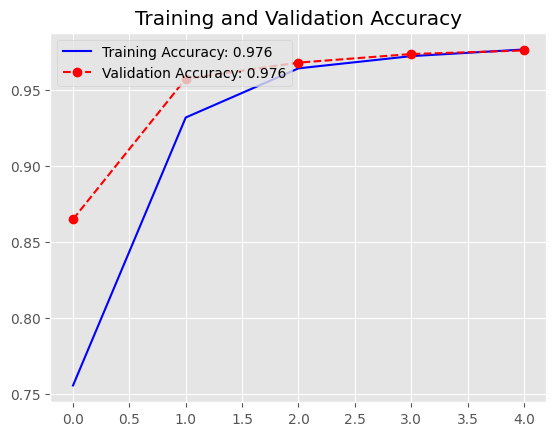

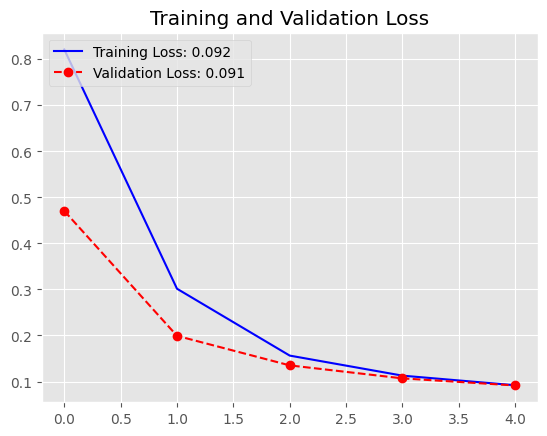

In [92]:
plot_accuracy(history, elapsed_time=None)

In [93]:
calculate_results(model_lstm)

1937/1937 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9758 - loss: 0.0914
test score:  0.09143374115228653
test accuracy:  0.9757797718048096
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
Accuracy: 0.975779775063334
Precision: 0.9759511991838691
Recall: 0.975779775063334
F1 Score: 0.9758094087271287
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      2250
           1       0.98      0.98      0.98      2222
           2       1.00      1.00      1.00     42211
           3       0.95      0.96      0.95      2217
           4       0.95      0.94      0.95      2100
           5       0.89      0.92      0.90      2248
           6       0.93      0.92      0.92      2215
           7       0.96      0.93      0.95      2079
           8       0.90      0.91      0.91      2234
           9       0.94      0.89      0.91      2197

    accuracy                           0.98     61973
   macro avg       0.94 

GRU

In [94]:
model_gru = gru_model(max_features, units=10, maxlen=avg_sequence_length)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 8, 50)          │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 10)             │         1,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,001,970 (3.82 MB)

 Trainable params: 1,001,970 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

None


In [95]:
elapsed_time, history=model_fit(model_gru,
                                X_train_padded, y_train,
                                X_test_padded, y_test)

Epoch 1/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 130s 16ms/step - accuracy: 0.7221 - loss: 0.9060 - val_accuracy: 0.7881 - val_loss: 0.6596
Epoch 2/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 124s 14ms/step - accuracy: 0.8310 - loss: 0.5503 - val_accuracy: 0.8680 - val_loss: 0.4534
Epoch 3/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 105s 14ms/step - accuracy: 0.9104 - loss: 0.3587 - val_accuracy: 0.9360 - val_loss: 0.2826
Epoch 4/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 124s 16ms/step - accuracy: 0.9521 - loss: 0.2239 - val_accuracy: 0.9588 - val_loss: 0.1863
Epoch 5/5
7747/7747 ━━━━━━━━━━━━━━━━━━━━ 129s 17ms/step - accuracy: 0.9650 - loss: 0.1531 - val_accuracy: 0.9673 - val_loss: 0.1371


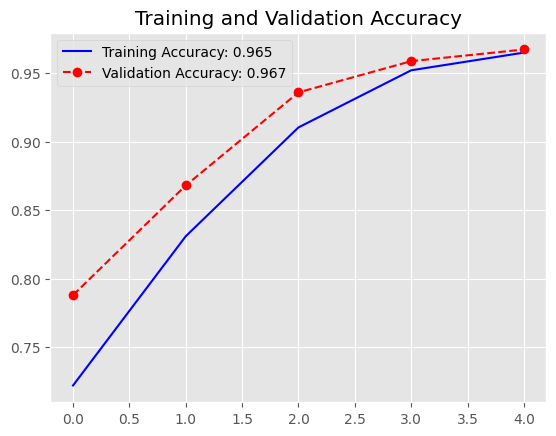

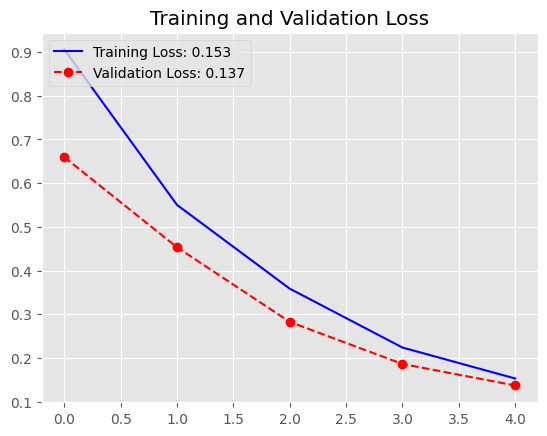

In [96]:
plot_accuracy(history, elapsed_time=None)

In [97]:
calculate_results(model_gru)

1937/1937 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9673 - loss: 0.1371
test score:  0.13708829879760742
test accuracy:  0.9672760963439941
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
Accuracy: 0.9672760718377358
Precision: 0.9683752172998308
Recall: 0.9672760718377358
F1 Score: 0.9674864506311976
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      2250
           1       0.99      0.96      0.97      2222
           2       1.00      1.00      1.00     42211
           3       0.88      0.94      0.91      2217
           4       0.94      0.90      0.92      2100
           5       0.93      0.85      0.89      2248
           6       0.93      0.85      0.89      2215
           7       0.93      0.91      0.92      2079
           8       0.89      0.90      0.89      2234
           9       0.79      0.90      0.84      2197

    accuracy                           0.97     61973
   macro avg       0.9